# Personalized Discount Prediction — Two-Stage Pipeline

### Stage 1: Uplift Modeling    → WHO gets a discount?
### Stage 2: Profit Optimization → HOW MUCH discount?

In [94]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
 
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (roc_auc_score, f1_score, classification_report,
                              precision_score, recall_score, confusion_matrix)
from sklearn.calibration import CalibratedClassifierCV, calibration_curve

In [95]:
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': '#F9F9F9',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.family': 'DejaVu Sans',
    'axes.titlesize': 13,
    'axes.labelsize': 11,
})
PURPLE = '#7F77DD'
TEAL = '#1D9E75'
CORAL = '#D85A30'
AMBER = '#BA7517'
GRAY = '#888780'

In [96]:
# Loading and Preprocessing the data
df = pd.read_csv('online_shoppers_intention.csv')
print(f"Loaded dataset: {df.shape[0]: ,} rows × {df.shape[1]} columns")

Loaded dataset:  12,330 rows × 18 columns


In [97]:
# We encode the categorical variables
le_month = LabelEncoder()
le_visitor = LabelEncoder()
df['Month_enc'] = le_month.fit_transform(df['Month'])
df['VisitorType_enc'] = le_visitor.fit_transform(df['VisitorType'])
df['Weekend_enc'] = df['Weekend'].astype(int)
df['Revenue_int'] = df['Revenue'].astype(int)
 
FEATURES = [
    'Administrative', 'Administrative_Duration',
    'Informational',  'Informational_Duration',
    'ProductRelated', 'ProductRelated_Duration',
    'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay',
    'Month_enc', 'OperatingSystems', 'Browser',
    'Region', 'TrafficType', 'VisitorType_enc', 'Weekend_enc'
]
 
X = df[FEATURES].values
y = df['Revenue_int'].values
 
print(f"Features used: {len(FEATURES)}")
print(f"Class balance - No purchase: {(y == 0).sum(): ,}  |  Purchase: {(y == 1).sum(): ,}")

Features used: 17
Class balance - No purchase:  10,422  |  Purchase:  1,908


In [98]:
# We split up the data into training and testing sets for the GBM to caculate the base probability.

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.2, random_state = 42, stratify = y
)

In [99]:
# We apply something known as 'Platt Scaling Calibration' to the GBM models.
# This iteration of the code is the first one being pushed via Git to GitHub.
# However, in previous iterations, we did not implement such a calibration.
# GBM models are notoriously known to produce overconfident probabilites (Niculescu-Mizil and Caruana, 2005).
# We learnt that Isotonic Regression calibration adjusts raw outputs such that
# when the model says p = 0.70, then around 70% of the said customers actually purchased.
# This in turn makes the probability input to our profit formula statistically and technically defensible.
# So we promptly applied it.
# We also employ a separate validation split so the calibrator learns on the data that
# the base model hasn't seen.

X_train2, X_cal, y_train2, y_cal = train_test_split(
    X_train, y_train, test_size = 0.2, random_state = 99, stratify = y_train
)
base_model_raw = GradientBoostingClassifier(
    n_estimators = 200, learning_rate = 0.05,
    max_depth = 4, subsample = 0.8, random_state = 42
)
base_model_raw.fit(X_train2, y_train2)

base_model_calibrated = CalibratedClassifierCV(
    base_model_raw, method = 'isotonic', cv = 5
)
base_model_calibrated.fit(X_cal, y_cal)

# We keep base_model reference for feature importances
base_model = base_model_raw

y_pred = base_model_calibrated.predict(X_test)
y_pred_prob = base_model_calibrated.predict_proba(X_test)[:, 1]

# Test
fraction_pos, mean_pred = calibration_curve(y_test, y_pred_prob, n_bins = 10)
calibration_error = np.mean(np.abs(fraction_pos - mean_pred))
print(f"Mean Calibration Error (post): {calibration_error: .4f}  (here, lower = better calibrated)")

auc = roc_auc_score(y_test, y_pred_prob)
f1 = f1_score(y_test, y_pred)
print(f"ROC-AUC: {auc: .4f}")
print(f"F1 Score: {f1: .4f}")
print(f"Precision: {precision_score(y_test, y_pred): .4f}")
print(f"Recall: {recall_score(y_test, y_pred): .4f}")

Mean Calibration Error (post):  0.0351  (here, lower = better calibrated)
ROC-AUC:  0.9183
F1 Score:  0.6368
Precision:  0.7120
Recall:  0.5759


In [100]:
# We are at the Stage I of the project, i.e., Uplift Modeling

# Treatment Assignment Strategy:
# We make use of two extremely strong proxies from the dataset to simulate treatment for the Treatment Group (discount exposure)
# The first one: SpecialDay > 0 (This indicates that the customer is near a sale event.
# We learnt something fun here. Contrary to common assumptions, people tend to buy less during the 'SpecialDay' itself,
# i.e., when SpecialDay = 1, i.e., on the day of the festival/holiday itself).
# The second one: New_Visitor (A first-time visitor probably saw a welcome discount)
# The Control Group would be regular returning visitors/customers on regular, non-special days.

df['Treatment'] = ((df['SpecialDay'] > 0) | (df['VisitorType'] == 'New_Visitor')).astype(int)

treated_pct = df['Treatment'].mean() * 100
print(f"Treatment group (discount-exposed): {df['Treatment'].sum(): ,} ({treated_pct: .1f}%)")
print(f"Control group (no discount): {(df['Treatment'] == 0).sum(): ,} ({100 - treated_pct: .1f}%)")
print(f"Conversion rate - Treatment: {df[df['Treatment'] == 1]['Revenue_int'].mean(): .3f}")
print(f"Conversion rate - Control: {df[df['Treatment'] == 0]['Revenue_int'].mean(): .3f}")

Treatment group (discount-exposed):  2,887 ( 23.4%)
Control group (no discount):  9,443 ( 76.6%)
Conversion rate - Treatment:  0.167
Conversion rate - Control:  0.151


In [101]:
# We start with T-Learner. We train separate models for treated & control groups.
df_treated = df[df['Treatment'] == 1]
df_control = df[df['Treatment'] == 0]

X_t = df_treated[FEATURES].values
y_t = df_treated['Revenue_int'].values
X_c = df_control[FEATURES].values
y_c = df_control['Revenue_int'].values

model_treated = GradientBoostingClassifier(
    n_estimators = 150, learning_rate = 0.08,
    max_depth = 3, random_state = 42
)
model_control = GradientBoostingClassifier(
    n_estimators = 150, learning_rate = 0.08,
    max_depth = 3, random_state = 42
)

In [102]:
# We apply Platt Scaling Calibration (for the T-Learner models)
# Both uplift models are calibrated independently on their own
# held-out splits so that the probability difference (uplift score)
# reflects a true causal effect estimate rather than raw
# overconfident GBM scores.

X_t_tr, X_t_cal, y_t_tr, y_t_cal = train_test_split(
    X_t, y_t, test_size = 0.2, random_state = 42, stratify = y_t
)
X_c_tr, X_c_cal, y_c_tr, y_c_cal = train_test_split(
    X_c, y_c, test_size = 0.2, random_state = 42, stratify = y_c
)

model_treated.fit(X_t_tr, y_t_tr)
model_control.fit(X_c_tr, y_c_tr)

model_treated_cal = CalibratedClassifierCV(
    model_treated, method = 'isotonic', cv = 5
)
model_treated_cal.fit(X_t_cal, y_t_cal)

model_control_cal = CalibratedClassifierCV(
    model_control, method = 'sigmoid', cv = 5
)
model_control_cal.fit(X_c_cal, y_c_cal)

print("T-Learner models trained and calibrated:")
print(f"Treatment model - trained on {len(X_t_tr): ,} | calibrated on {len(X_t_cal): ,} samples")
print(f"Control model  - trained on {len(X_c_tr): ,} | calibrated on {len(X_c_cal): ,} samples")

T-Learner models trained and calibrated:
Treatment model - trained on  2,309 | calibrated on  578 samples
Control model  - trained on  7,554 | calibrated on  1,889 samples


In [103]:
# We now compute Uplift Scores using the calibrated models
X_all = df[FEATURES].values

p_treatment = model_treated_cal.predict_proba(X_all)[:, 1]    # calibrated P(buy | discount)
p_control = model_control_cal.predict_proba(X_all)[:, 1]    # calibrated P(buy | no discount)
uplift = p_treatment - p_control    # Individual Treatment Effect

df['p_treatment'] = p_treatment
df['p_control'] = p_control
df['uplift_score'] = uplift

print(f"Uplift score stats: ")
print(f"Mean: {uplift.mean(): .4f}")
print(f"Std: {uplift.std(): .4f}")
print(f"Min: {uplift.min(): .4f}")
print(f"Max: {uplift.max(): .4f}")

Uplift score stats: 
Mean:  0.0471
Std:  0.1472
Min: -0.6919
Max:  0.7959


In [104]:
# Our final task here is Customer Segmentation
# We divide the customer into 'Pursuadables' (customers who need a little incentive to buy and can be converted to being a customer), 
# 'Sure Things' (customers who will buy regardless of incentives, i.e., they don't need one), 
# and 'Lost Causes' (customers who won't buy regardless of the incentives they're given.)
# This is obviously standard naming for uplift modeling.
# Persuadables : uplift > 0.05  (a discount would meaningfully help)
# Sure Things : uplift <= 0.05 & p_control > 0.5  (would buy anyway)
# Lost Causes : uplift <= 0.05 & p_control <= 0.5 (won't buy regardless)

UPLIFT_THRESHOLD = 0.05

def segment(row):
    if row['uplift_score'] > UPLIFT_THRESHOLD:
        return 'Persuadable'
    elif row['p_control'] > 0.5:
        return 'Sure Thing'
    else:
        return 'Lost Cause'

df['segment'] = df.apply(segment, axis=1)

seg_counts = df['segment'].value_counts()
print(f"Customer Segments:")
for seg, count in seg_counts.items():
    percent = count / len(df) * 100
    conv = df[df['segment'] == seg]['Revenue_int'].mean()
    print(f"{seg:15s}: {count:5,} ({percent:5.1f}%) | Actual conversion: {conv:.3f}")

Customer Segments:
Lost Cause     : 7,910 ( 64.2%) | Actual conversion: 0.048
Persuadable    : 4,000 ( 32.4%) | Actual conversion: 0.307
Sure Thing     :   420 (  3.4%) | Actual conversion: 0.714


In [105]:
# We are at the Stage II of the project, i.e., Profit Optimization

# We use the following discount tiers to evaluate
DISCOUNT_TIERS = [0.0, 0.05, 0.10, 0.15, 0.20]

# The 'Revenue' proxy: PageValues, which captures the value of pages visited
# We normalize and scale to a reasonable revenue range ($20 – $200)
# Using the following formula, we simulate purchase amounts.

page_vals = df['PageValues'].values
page_min, page_max = page_vals.min(), page_vals.max() + 1e-9
df['revenue_proxy'] = 20 + (page_vals - page_min) / (page_max - page_min) * 180

# Here, we introduce 'Price Elasticity', which means higher discounts would boost purchase probability
# The Elasticity factor is what we use. It varies by segment sensitivity.
ELASTICITY = 1.5    # Each 10% discount would lift P(buy) by ~ elasticity × 10%

def expected_profit(p_buy_base, discount, revenue, cost_ratio = 0.4):
    # The following is the formula we used to calculate expected profit
    """
    Expected Profit = P(purchase | discount) × (revenue − cost − discount_amount)
                    − small fixed cost of sending offer
    """
    lift = ELASTICITY * discount    # uplift from discount
    p_buy_discounted = min(p_buy_base + lift, 0.99)    # capped at 99%
    gross_margin = revenue * (1 - cost_ratio)    # cost is 40% of revenue
    discount_amount = revenue * discount
    offer_cost = 0.50    # $0.50 to send offer
    profit = p_buy_discounted * (gross_margin - discount_amount) - offer_cost
    return profit, p_buy_discounted

# We need to run the optimization only on the 'Pursuadables'.
# The 'Pursuadables' are the target demographic here, since they're the only ones that
# can be meaningfully pushed to buy and be converted into a customer.
persuadables = df[df['segment'] == 'Persuadable'].copy()
print(f"Optimizing discounts for {len(persuadables):,} persuadable customers...")

results = []
for idx, row in persuadables.iterrows():
    best_profit = -999
    best_discount = 0.0
    best_p_buy = row['p_treatment']

    for d in DISCOUNT_TIERS:
        profit, p_buy = expected_profit(
            row['p_treatment'], d, row['revenue_proxy']
        )
        if profit > best_profit:
            best_profit = profit
            best_discount = d
            best_p_buy = p_buy

    results.append({
        'idx': idx,
        'segment': 'Persuadable',
        'uplift_score': row['uplift_score'],
        'p_buy_no_disc': row['p_control'],
        'p_buy_with_disc': best_p_buy,
        'optimal_discount': best_discount,
        'revenue_proxy': row['revenue_proxy'],
        'expected_profit': best_profit,
        'actual_purchase': row['Revenue_int'],
        'visitor_type': row['VisitorType'],
        'special_day': row['SpecialDay'],
    })

results_df = pd.DataFrame(results)

print(f"Discount Distribution among Persuadables:")
disc_dist = results_df['optimal_discount'].value_counts().sort_index()
for disc, count in disc_dist.items():
    bar = '█' * int(count / len(results_df) * 40)
    print(f"{int(disc*100):3d}% {bar}  {count:,} customers ({count/len(results_df)*100:.1f}%)")

print(f"Expected Profit Stats (Persuadables only):")
print(f"Mean expected profit: ${results_df['expected_profit'].mean(): .2f}")
print(f"Total expected profit: ${results_df['expected_profit'].sum():,.2f}")

# We also need to compute the profit we'd get with no discount
no_discount_profit = []
for idx, row in persuadables.iterrows():
    p, _ = expected_profit(row['p_control'], 0.0,
                           df.loc[idx, 'revenue_proxy'])
    no_discount_profit.append(p)

total_optimized = results_df['expected_profit'].sum()
total_no_discount = sum(no_discount_profit)
profit_gain = total_optimized - total_no_discount

print(f"\nProfit comparison (Persuadables):")
print(f"Without personalized discount: ${total_no_discount:,.2f}")
print(f"With personalized discount: ${total_optimized:,.2f}")
print(f"Profit gain from optimization: ${profit_gain:,.2f}")

Optimizing discounts for 4,000 persuadable customers...
Discount Distribution among Persuadables:
  0% ██████████  1,049 customers (26.2%)
  5% ███  393 customers (9.8%)
 10% ██  256 customers (6.4%)
 15% █  194 customers (4.9%)
 20% █████████████████████  2,108 customers (52.7%)
Expected Profit Stats (Persuadables only):
Mean expected profit: $ 9.63
Total expected profit: $38,505.77

Profit comparison (Persuadables):
Without personalized discount: $20,373.15
With personalized discount: $38,505.77
Profit gain from optimization: $18,132.61


In [106]:
# We now build the final recommendation table that summarizes everything

# We combine all segments into the final output
final_df = df[['Revenue_int', 'VisitorType', 'segment',
               'uplift_score', 'p_control', 'p_treatment',
               'revenue_proxy']].copy()

# The non-pursuadable group, i.e., the 'Sure Thing' and 'Lost Cause' demographics get no discount
final_df['optimal_discount'] = 0.0
final_df['expected_profit'] = 0.0

for r in results:
    final_df.loc[r['idx'], 'optimal_discount'] = r['optimal_discount']
    final_df.loc[r['idx'], 'expected_profit']  = r['expected_profit']

print(f"Total customers evaluated: {len(final_df):,}")
print(f"Customers receiving discount: {(final_df['optimal_discount'] > 0).sum():,}")
print(f"Customers getting no discount: {(final_df['optimal_discount'] == 0).sum():,}")

print(f"\nSegment breakdown:")
for seg in ['Persuadable', 'Sure Thing', 'Lost Cause']:
    sub = final_df[final_df['segment'] == seg]
    avg_disc = sub['optimal_discount'].mean() * 100
    print(f"{seg:15s}: {len(sub):5,} customers | avg discount: {avg_disc:.1f}%")

Total customers evaluated: 12,330
Customers receiving discount: 2,951
Customers getting no discount: 9,379

Segment breakdown:
Persuadable    : 4,000 customers | avg discount: 12.4%
Sure Thing     :   420 customers | avg discount: 0.0%
Lost Cause     : 7,910 customers | avg discount: 0.0%


Generating visualizations...
Saved: discount_pipeline_results.png


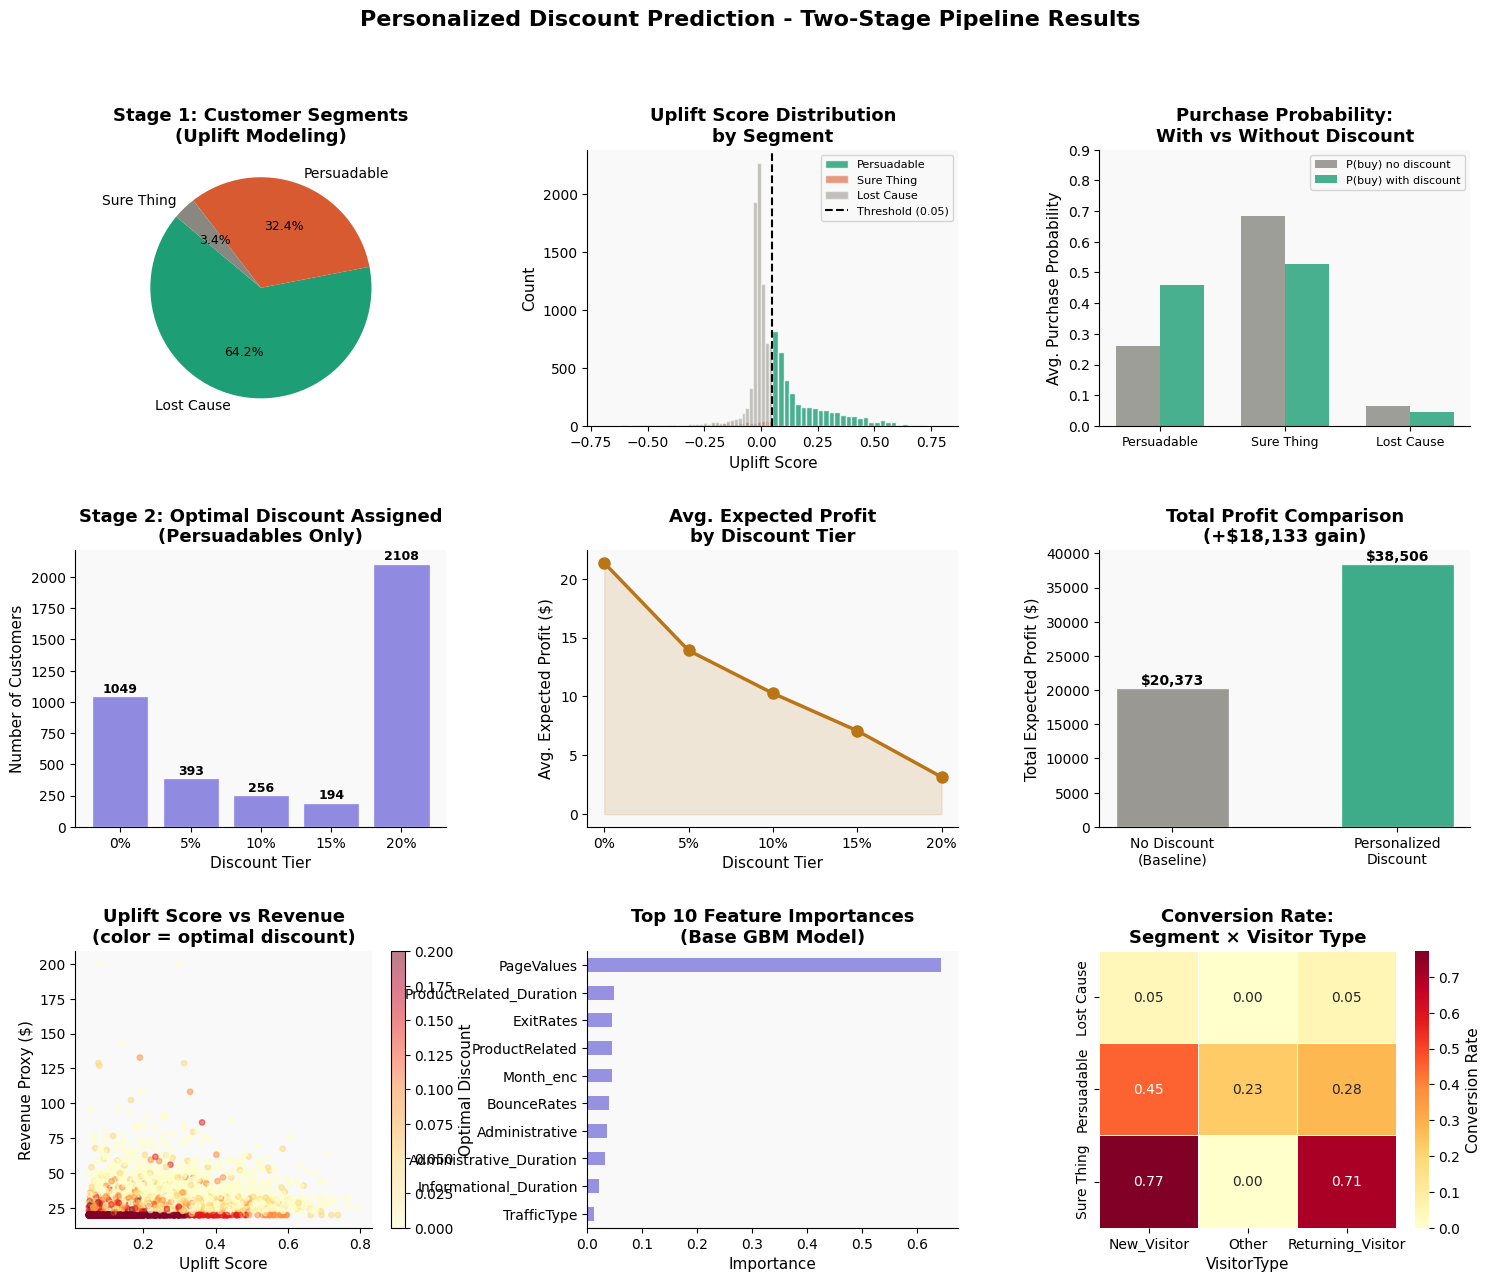

In [107]:
# And now we finally map out some visualizations, as part of the summary
print("Generating visualizations...")
 
fig = plt.figure(figsize = (18, 14))
fig.suptitle('Personalized Discount Prediction - Two-Stage Pipeline Results',
             fontsize = 16, fontweight = 'bold', y = 0.98)
gs = gridspec.GridSpec(3, 3, figure = fig, hspace = 0.45, wspace = 0.38)

# Plot 1: Customer Segments Pie Chart
ax1 = fig.add_subplot(gs[0, 0])
colors = [TEAL, CORAL, GRAY]
seg_labels = seg_counts.index.tolist()
seg_vals = seg_counts.values.tolist()
wedges, texts, autotexts = ax1.pie(
    seg_vals, labels = seg_labels, colors = colors,
    autopct = '%1.1f%%', startangle = 140,
    textprops = {'fontsize': 10}
)

for at in autotexts:
    at.set_fontsize(9)
ax1.set_title('Stage 1: Customer Segments\n(Uplift Modeling)', fontweight = 'bold')

# Plot 2: Uplift Score Distribution
ax2 = fig.add_subplot(gs[0, 1])
ax2.hist(df[df['segment'] == 'Persuadable']['uplift_score'],
         bins = 30, color = TEAL, alpha = 0.8, label = 'Persuadable', edgecolor = 'white')
ax2.hist(df[df['segment'] == 'Sure Thing']['uplift_score'],
         bins = 30, color = CORAL, alpha = 0.6, label = 'Sure Thing', edgecolor = 'white')
ax2.hist(df[df['segment'] == 'Lost Cause']['uplift_score'],
         bins = 30, color = GRAY, alpha = 0.5, label = 'Lost Cause', edgecolor = 'white')
ax2.axvline(UPLIFT_THRESHOLD, color = 'black', linestyle = '--', linewidth = 1.5,
            label=f'Threshold ({UPLIFT_THRESHOLD})')
ax2.set_xlabel('Uplift Score')
ax2.set_ylabel('Count')
ax2.set_title('Uplift Score Distribution\nby Segment', fontweight = 'bold')
ax2.legend(fontsize = 8)

# Plot 3: P(buy) with vs without discount per segment
ax3 = fig.add_subplot(gs[0, 2])
seg_order = ['Persuadable', 'Sure Thing', 'Lost Cause']
p_ctrl_means = [df[df['segment'] == s]['p_control'].mean() for s in seg_order]
p_trt_means = [df[df['segment'] == s]['p_treatment'].mean() for s in seg_order]
x_pos = np.arange(len(seg_order))
w = 0.35
ax3.bar(x_pos - w / 2, p_ctrl_means, w, label = 'P(buy) no discount',
        color = GRAY, alpha = 0.8)
ax3.bar(x_pos + w / 2, p_trt_means,  w, label = 'P(buy) with discount',
        color = TEAL, alpha=0.8)
ax3.set_xticks(x_pos)
ax3.set_xticklabels(seg_order, fontsize = 9)
ax3.set_ylabel('Avg. Purchase Probability')
ax3.set_title('Purchase Probability:\nWith vs Without Discount', fontweight = 'bold')
ax3.legend(fontsize = 8)
ax3.set_ylim(0, 0.9)

# Plot 4: Optimal Discount Distribution
ax4 = fig.add_subplot(gs[1, 0])
disc_pct = (results_df['optimal_discount'] * 100).astype(int)
disc_counts = disc_pct.value_counts().sort_index()
bars = ax4.bar([f"{d}%" for d in disc_counts.index], disc_counts.values,
               color = PURPLE, alpha = 0.85, edgecolor = 'white')
for bar, val in zip(bars, disc_counts.values):
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
             str(val), ha = 'center', va = 'bottom', fontsize = 9, fontweight = 'bold')
ax4.set_xlabel('Discount Tier')
ax4.set_ylabel('Number of Customers')
ax4.set_title('Stage 2: Optimal Discount Assigned\n(Persuadables Only)', fontweight = 'bold')

# Plot 5: Expected Profit by Discount Tier
ax5 = fig.add_subplot(gs[1, 1])
avg_profit_by_disc = results_df.groupby('optimal_discount')['expected_profit'].mean()
ax5.plot([f"{int(d*100)}%" for d in avg_profit_by_disc.index],
         avg_profit_by_disc.values,
         marker = 'o', color = AMBER, linewidth = 2.5, markersize = 8)
ax5.fill_between(range(len(avg_profit_by_disc)),
                 avg_profit_by_disc.values, alpha = 0.15, color = AMBER)
ax5.set_xticks(range(len(avg_profit_by_disc)))
ax5.set_xticklabels([f"{int(d*100)}%" for d in avg_profit_by_disc.index])
ax5.set_xlabel('Discount Tier')
ax5.set_ylabel('Avg. Expected Profit ($)')
ax5.set_title('Avg. Expected Profit\nby Discount Tier', fontweight = 'bold')

# Plot 6: Profit Gain Comparison Bar
ax6 = fig.add_subplot(gs[1, 2])
categories = ['No Discount\n(Baseline)', 'Personalized\nDiscount']
values = [total_no_discount, total_optimized]
bar_colors = [GRAY, TEAL]
bars2 = ax6.bar(categories, values, color = bar_colors, alpha = 0.85,
                edgecolor = 'white', width = 0.5)
for bar, val in zip(bars2, values):
    ax6.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
             f'${val:,.0f}', ha = 'center', va = 'bottom',
             fontsize = 10, fontweight = 'bold')
ax6.set_ylabel('Total Expected Profit ($)')
ax6.set_title(f'Total Profit Comparison\n(+${profit_gain:,.0f} gain)', fontweight = 'bold')

# Plot 7: Uplift Score vs Revenue Proxy (Persuadables)
ax7 = fig.add_subplot(gs[2, 0])
sc = ax7.scatter(
    results_df['uplift_score'],
    results_df['revenue_proxy'],
    c = results_df['optimal_discount'],
    cmap = 'YlOrRd', alpha = 0.5, s = 15
)
plt.colorbar(sc, ax = ax7, label = 'Optimal Discount')
ax7.set_xlabel('Uplift Score')
ax7.set_ylabel('Revenue Proxy ($)')
ax7.set_title('Uplift Score vs Revenue\n(color = optimal discount)', fontweight = 'bold')

# Plot 8: Feature Importance (Base Model)
ax8 = fig.add_subplot(gs[2, 1])
importances = base_model.feature_importances_
feat_imp = pd.Series(importances, index = FEATURES).sort_values(ascending = True).tail(10)
feat_imp.plot(kind = 'barh', ax = ax8, color = PURPLE, alpha = 0.8)
ax8.set_title('Top 10 Feature Importances\n(Base GBM Model)', fontweight = 'bold')
ax8.set_xlabel('Importance')

# Plot 9: Segment × Visitor Type Heatmap
ax9 = fig.add_subplot(gs[2, 2])
pivot = df.groupby(['segment', 'VisitorType'])['Revenue_int'].mean().unstack(fill_value = 0)
sns.heatmap(pivot, ax = ax9, cmap = 'YlOrRd', annot = True, fmt = '.2f',
            linewidths = 0.5, cbar_kws = {'label': 'Conversion Rate'})
ax9.set_title('Conversion Rate:\nSegment × Visitor Type', fontweight = 'bold')
ax9.set_ylabel('')

plt.savefig('discount_pipeline_results.png',
            dpi = 150, bbox_inches = 'tight')
print("Saved: discount_pipeline_results.png")